In [1]:
import pandas as pd
df = pd.read_csv("C:/Users/tarun/Downloads/archive (1)/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.shape

(1025, 14)

In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
x = df.drop(columns=["target"])

In [6]:
y=df["target"]

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier 

In [11]:
from sklearn.model_selection import cross_val_score
models_cv = [
    LogisticRegression(max_iter=1000, random_state=42),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    XGBClassifier(eval_metric="logloss", random_state=42),
    GaussianNB(),
    KNeighborsClassifier()
]
names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Naive Bayes",
    "KNN"
]
for name, model in zip(names, models_cv):
    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    print(name + " CV Accuracy:", round(scores.mean(), 4))

Logistic Regression CV Accuracy: 0.8488
Decision Tree CV Accuracy: 0.9756
Random Forest CV Accuracy: 0.9817
XGBoost CV Accuracy: 0.9805
Naive Bayes CV Accuracy: 0.8317
KNN CV Accuracy: 0.8427


In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, matthews_corrcoef,
                              confusion_matrix, roc_curve, ConfusionMatrixDisplay)

Lr = LogisticRegression(max_iter=1000, random_state=42)
Lr.fit(x_train,y_train)
Lr_pred = Lr.predict(x_test)
Lr_prob = Lr.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, Lr_pred).ravel()
Lr_accuracy = accuracy_score(y_test, Lr_pred)
Lr_precision = precision_score(y_test, Lr_pred)
Lr_recall = recall_score(y_test, Lr_pred)
Lr_f1= f1_score(y_test, Lr_pred)
Lr_specificity = tn / (tn + fp)
Lr_mcc = matthews_corrcoef(y_test, Lr_pred)
Lr_auc = roc_auc_score(y_test, Lr_prob)

print("Logistic Regression")
print("Accuracy Score: ", round(Lr_accuracy,4))
print("Precision Score: ", round(Lr_precision,4))
print("Recall Score: ", round(Lr_recall,4))
print("f1 Score: ", round(Lr_f1,4))
print("Specificity: ", round(Lr_specificity,4))
print("MCC: ", round(Lr_mcc,4))
print("AUC: ", round(Lr_auc,4))

Logistic Regression
Accuracy Score:  0.7951
Precision Score:  0.7563
Recall Score:  0.8738
f1 Score:  0.8108
Specificity:  0.7157
MCC:  0.5973
AUC:  0.8787


In [13]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
dt_prob = dt.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, dt_pred).ravel()
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1= f1_score(y_test, dt_pred)
dt_specificity = tn / (tn + fp)
dt_mcc = matthews_corrcoef(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree")
print("Accuracy Score: ", round(dt_accuracy,4))
print("Precision Score: ", round(dt_precision,4))
print("Recall Score: ", round(dt_recall,4))
print("f1 Score: ", round(dt_f1,4))
print("Specificity: ", round(dt_specificity,4))
print("MCC: ", round(dt_mcc,4))
print("AUC: ", round(dt_auc,4))

Decision Tree
Accuracy Score:  0.9854
Precision Score:  1.0
Recall Score:  0.9709
f1 Score:  0.9852
Specificity:  1.0
MCC:  0.9712
AUC:  0.9854


In [14]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train,y_train)
rfc_pred = rfc.predict(x_test)
rfc_prob = rfc.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, rfc_pred).ravel()
rfc_accuracy = accuracy_score(y_test, rfc_pred)
rfc_precision = precision_score(y_test, rfc_pred)
rfc_recall = recall_score(y_test, rfc_pred)
rfc_f1= f1_score(y_test, rfc_pred)
rfc_specificity = tn / (tn + fp)
rfc_mcc = matthews_corrcoef(y_test, rfc_pred)
rfc_auc = roc_auc_score(y_test, rfc_prob)

print("Random Forest Classifier")
print("Accuracy Score: ", round(rfc_accuracy,4))
print("Precision Score: ", round(rfc_precision,4))
print("Recall Score: ", round(rfc_recall,4))
print("f1 Score: ", round(rfc_f1,4))
print("Specificity: ", round(rfc_specificity,4))
print("MCC: ", round(rfc_mcc,4))
print("AUC: ", round(rfc_auc,4))

Random Forest Classifier
Accuracy Score:  0.9854
Precision Score:  1.0
Recall Score:  0.9709
f1 Score:  0.9852
Specificity:  1.0
MCC:  0.9712
AUC:  1.0


In [15]:
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(x_train,y_train)
xgb_pred = xgb.predict(x_test)
xgb_prob = xgb.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1= f1_score(y_test, xgb_pred)
xgb_specificity = tn / (tn + fp)
xgb_mcc = matthews_corrcoef(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Classifier")
print("Accuracy Score: ", round(xgb_accuracy,4))
print("Precision Score: ", round(xgb_precision,4))
print("Recall Score: ", round(xgb_recall,4))
print("f1 Score: ", round(xgb_f1,4))
print("Specificity: ", round(xgb_specificity,4))
print("MCC: ", round(xgb_mcc,4))
print("AUC: ", round(xgb_auc,4))

XGBoost Classifier
Accuracy Score:  0.9854
Precision Score:  1.0
Recall Score:  0.9709
f1 Score:  0.9852
Specificity:  1.0
MCC:  0.9712
AUC:  0.9894


In [16]:
nb = GaussianNB()
nb.fit(x_train,y_train)
nb_pred = nb.predict(x_test)
nb_prob = nb.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, nb_pred).ravel()
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1= f1_score(y_test, nb_pred)
nb_specificity = tn / (tn + fp)
nb_mcc = matthews_corrcoef(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print("Naive Bayes Classifier")
print("Accuracy Score: ", round(nb_accuracy,4))
print("Precision Score: ", round(nb_precision,4))
print("Recall Score: ", round(nb_recall,4))
print("f1 Score: ", round(nb_f1,4))
print("Specificity: ", round(nb_specificity,4))
print("MCC: ", round(nb_mcc,4))
print("AUC: ", round(nb_auc,4))

Naive Bayes Classifier
Accuracy Score:  0.8
Precision Score:  0.7541
Recall Score:  0.8932
f1 Score:  0.8178
Specificity:  0.7059
MCC:  0.6102
AUC:  0.8706


In [17]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
knn_pred = knn.predict(x_test)
knn_prob = knn.predict_proba(x_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, knn_pred).ravel()
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1= f1_score(y_test, knn_pred)
knn_specificity = tn / (tn + fp)
knn_mcc = matthews_corrcoef(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_prob)

print("KNeighbors Classifier")
print("Accuracy Score: ", round(knn_accuracy,4))
print("Precision Score: ", round(knn_precision,4))
print("Recall Score: ", round(knn_recall,4))
print("f1 Score: ", round(knn_f1,4))
print("Specificity: ", round(knn_specificity,4))
print("MCC: ", round(knn_mcc,4))
print("AUC: ", round(knn_auc,4))

KNeighbors Classifier
Accuracy Score:  0.8341
Precision Score:  0.8
Recall Score:  0.8932
f1 Score:  0.844
Specificity:  0.7745
MCC:  0.6727
AUC:  0.9486


In [18]:
results_df = pd.DataFrame({
    "Logistic Regression": [
        Lr_accuracy,
        Lr_precision,
        Lr_recall,
        Lr_f1,
        Lr_specificity,
        Lr_mcc,
        Lr_auc
    ],
    
    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_specificity,
        dt_mcc,
        dt_auc
    ],
    
    "Random Forest": [
        rfc_accuracy,
        rfc_precision,
        rfc_recall,
        rfc_f1,
        rfc_specificity,
        rfc_mcc,
        rfc_auc
    ],
    
    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_specificity,
        xgb_mcc,
        xgb_auc
    ],
    
    "Naive Bayes": [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1,
        nb_specificity,
        nb_mcc,
        nb_auc
    ],
    
    "KNN": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1,
        knn_specificity,
        knn_mcc,
        knn_auc
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "MCC",
    "AUC"
])
results_df = results_df.round(4)
results_df

,Logistic Regression,Decision Tree,Random Forest,XGBoost,Naive Bayes,KNN
Accuracy,0.7951,0.9854,0.9854,0.9854,0.8000,0.8341
Precision,0.7563,1.0000,1.0000,1.0000,0.7541,0.8000
Recall,0.8738,0.9709,0.9709,0.9709,0.8932,0.8932
F1,0.8108,0.9852,0.9852,0.9852,0.8178,0.8440
Specificity,0.7157,1.0000,1.0000,1.0000,0.7059,0.7745
MCC,0.5973,0.9712,0.9712,0.9712,0.6102,0.6727
AUC,0.8787,0.9854,1.0000,0.9894,0.8706,0.9486


In [19]:
from sklearn.ensemble import StackingClassifier
base_estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('nb', GaussianNB()),
    ('knn', KNeighborsClassifier())
]

stack_model = StackingClassifier(
    estimators = base_estimators,
    final_estimator = LogisticRegression(max_iter=1000),
    cv=5
)

stack_model.fit(x_train,y_train)

from sklearn.model_selection import cross_val_score

stack_cv_scores = cross_val_score(stack_model, x_train, y_train, cv=5, scoring="accuracy")
print("Stacking Ensemble CV Accuracy:", round(stack_cv_scores.mean(), 4))

stack_pred = stack_model.predict(x_test)
stack_prob = stack_model.predict_proba(x_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, stack_pred).ravel()
stack_accuracy = accuracy_score(y_test, stack_pred)
stack_precision = precision_score(y_test, stack_pred)
stack_recall = recall_score(y_test, stack_pred)
stack_f1= f1_score(y_test, stack_pred)
stack_specificity = tn / (tn + fp)
stack_mcc = matthews_corrcoef(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_prob)

print("Stack Ensemble")
print("Accuracy Score: ", round(stack_accuracy,4))
print("Precision Score: ", round(stack_precision,4))
print("Recall Score: ", round(stack_recall,4))
print("f1 Score: ", round(stack_f1,4))
print("Specificity: ", round(stack_specificity,4))
print("MCC: ", round(stack_mcc,4))
print("AUC: ", round(stack_auc,4))

Stacking Ensemble CV Accuracy: 0.9768
Stack Ensemble
Accuracy Score:  0.9854
Precision Score:  1.0
Recall Score:  0.9709
f1 Score:  0.9852
Specificity:  1.0
MCC:  0.9712
AUC:  1.0


In [20]:
cv_accuracy = {
    "Logistic Regression": 0.8488,
    "Decision Tree": 0.9756,
    "Random Forest": 0.9817,
    "XGBoost": 0.9805,
    "Naive Bayes": 0.8317,
    "KNN": 0.8427,
    "Stacking Ensemble": 0.9768
}

cv_df = pd.DataFrame.from_dict(cv_accuracy, orient="index", columns=["CV Accuracy"])
print(cv_df)

                     CV Accuracy
Logistic Regression       0.8488
Decision Tree             0.9756
Random Forest             0.9817
XGBoost                   0.9805
Naive Bayes               0.8317
KNN                       0.8427
Stacking Ensemble         0.9768


In [21]:
results_df = results_df.T

In [22]:
results_df.loc["Stacking Ensemble"] = [
    stack_accuracy,
    stack_precision,
    stack_recall,
    stack_f1,
    stack_specificity,
    stack_mcc,
    stack_auc
]
results_df = results_df.round(4)
results_df

,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC
Logistic Regression,0.7951,0.7563,0.8738,0.8108,0.7157,0.5973,0.8787
Decision Tree,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,0.9854
Random Forest,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,1.0000
XGBoost,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,0.9894
Naive Bayes,0.8000,0.7541,0.8932,0.8178,0.7059,0.6102,0.8706
KNN,0.8341,0.8000,0.8932,0.8440,0.7745,0.6727,0.9486
Stacking Ensemble,0.9854,1.0000,0.9709,0.9852,1.0000,0.9712,1.0000


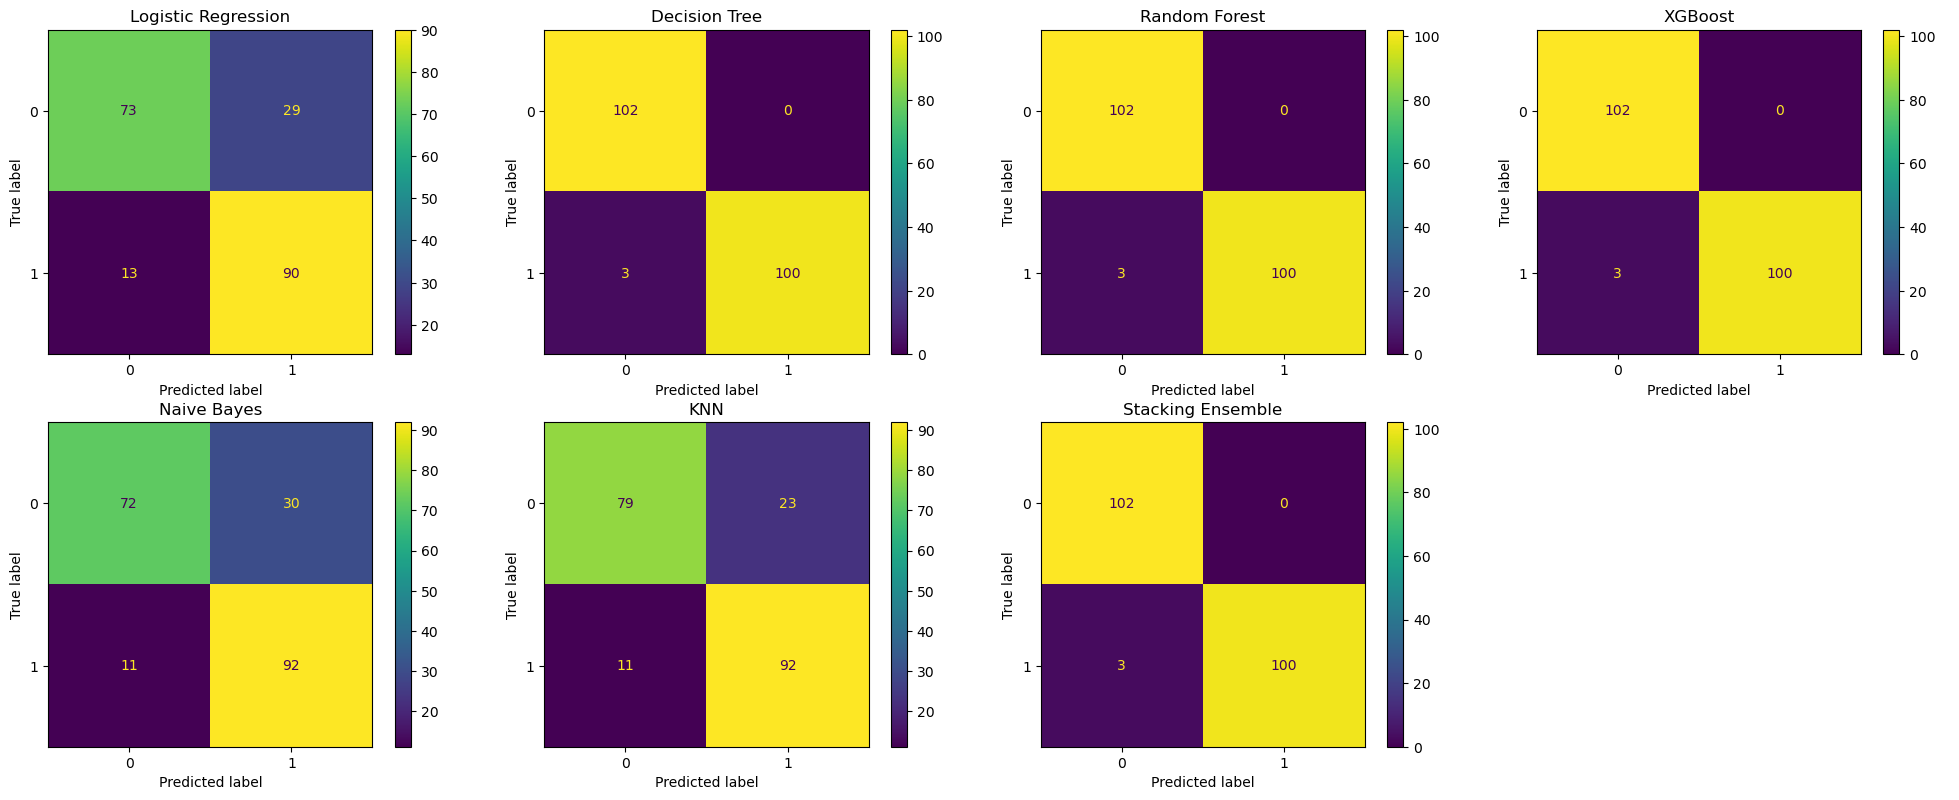

In [23]:
#Confusion Matrix
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

models_list = [
    ("Logistic Regression", Lr),
    ("Decision Tree", dt),
    ("Random Forest", rfc),
    ("XGBoost", xgb),
    ("Naive Bayes", nb),
    ("KNN", knn),
    ("Stacking Ensemble", stack_model)
]

for i, (name, model) in enumerate(models_list):
    preds = model.predict(x_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        ax=axes[i]
    )
    axes[i].set_title(name)

axes[7].axis("off")
plt.tight_layout()
plt.show()

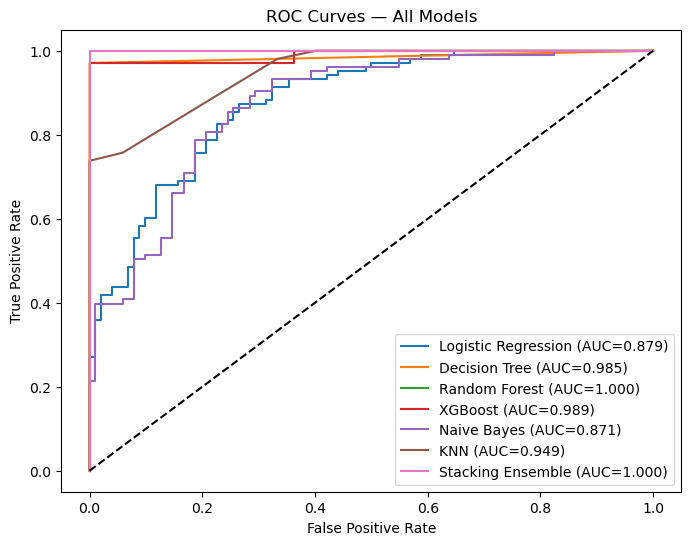

In [24]:
plt.figure(figsize=(8, 6))

for name, model in models_list:
    proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

In [83]:
df.duplicated().sum()

np.int64(723)

In [25]:
train_rows = set(map(tuple, x_train))
test_rows = set(map(tuple, x_test))

overlap = train_rows.intersection(test_rows)

print("Number of overlapping rows:", len(overlap))

Number of overlapping rows: 154


#Part 2: My Own solution 

In [28]:
df_clean = df.drop_duplicates().reset_index(drop=True)

In [29]:
df.shape

(1025, 14)

In [30]:
df_clean.shape

(302, 14)

In [34]:
x_clean = df_clean.drop(columns=["target"])
y_clean = df_clean["target"]

In [37]:
x_trainc,x_testc,y_trainc,y_testc = train_test_split(x_clean,y_clean,test_size=0.2,random_state=42)

In [81]:
overlap_clean = set(map(tuple, x_trainc)).intersection(set(map(tuple, x_testc)))
print("Overlapping rows after dedup:", len(overlap_clean))

Overlapping rows after dedup: 0


In [39]:
scaler_c = StandardScaler()
x_trainc = scaler_c.fit_transform(x_trainc)
x_testc = scaler_c.transform(x_testc)

In [42]:
Lr_c = LogisticRegression(max_iter=1000, random_state=42)
Lr_c.fit(x_trainc,y_trainc)
Lr_predc = Lr_c.predict(x_testc)
Lr_probc = Lr_c.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, Lr_predc).ravel()
Lr_c_accuracy = accuracy_score(y_testc, Lr_predc)
Lr_c_precision = precision_score(y_testc, Lr_predc)
Lr_c_recall = recall_score(y_testc, Lr_predc)
Lr_c_f1= f1_score(y_testc, Lr_predc)
Lr_c_specificity = tn / (tn + fp)
Lr_c_mcc = matthews_corrcoef(y_testc, Lr_predc)
Lr_c_auc = roc_auc_score(y_testc , Lr_probc)

print("Logistic Regression (clean)")
print("Accuracy Score: ", round(Lr_c_accuracy,4))
print("Precision Score: ", round(Lr_c_precision,4))
print("Recall Score: ", round(Lr_c_recall,4))
print("f1 Score: ", round(Lr_c_f1,4))
print("Specificity: ", round(Lr_c_specificity,4))
print("MCC: ", round(Lr_c_mcc,4))
print("AUC: ", round(Lr_c_auc,4))

Logistic Regression (clean)
Accuracy Score:  0.7705
Precision Score:  0.7027
Recall Score:  0.8966
f1 Score:  0.7879
Specificity:  0.6562
MCC:  0.5651
AUC:  0.8341


In [44]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(x_trainc,y_trainc)
dt_predc = dtc.predict(x_testc)
dt_probc = dtc.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, dt_predc).ravel()
dtc_accuracy = accuracy_score(y_testc, dt_predc)
dtc_precision = precision_score(y_testc, dt_predc)
dtc_recall = recall_score(y_testc, dt_predc)
dtc_f1= f1_score(y_testc, dt_predc)
dtc_specificity = tn / (tn + fp)
dtc_mcc = matthews_corrcoef(y_testc, dt_predc)
dtc_auc = roc_auc_score(y_testc, dt_probc)

print("Decision Tree (clean)")
print("Accuracy Score: ", round(dtc_accuracy,4))
print("Precision Score: ", round(dtc_precision,4))
print("Recall Score: ", round(dtc_recall,4))
print("f1 Score: ", round(dtc_f1,4))
print("Specificity: ", round(dtc_specificity,4))
print("MCC: ", round(dtc_mcc,4))
print("AUC: ", round(dtc_auc,4))

Decision Tree (clean)
Accuracy Score:  0.7377
Precision Score:  0.7407
Recall Score:  0.6897
f1 Score:  0.7143
Specificity:  0.7812
MCC:  0.4735
AUC:  0.7355


In [45]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_trainc,y_trainc)
rf_pred = rf.predict(x_testc)
rf_prob = rf.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, rf_pred).ravel()
rf_accuracy = accuracy_score(y_testc, rf_pred)
rf_precision = precision_score(y_testc, rf_pred)
rf_recall = recall_score(y_testc, rf_pred)
rf_f1= f1_score(y_testc, rf_pred)
rf_specificity = tn / (tn + fp)
rf_mcc = matthews_corrcoef(y_testc, rf_pred)
rf_auc = roc_auc_score(y_testc, rf_prob)

print("Random Forest Classifier (clean)")
print("Accuracy Score: ", round(rf_accuracy,4))
print("Precision Score: ", round(rf_precision,4))
print("Recall Score: ", round(rf_recall,4))
print("f1 Score: ", round(rf_f1,4))
print("Specificity: ", round(rf_specificity,4))
print("MCC: ", round(rf_mcc,4))
print("AUC: ", round(rf_auc,4))

Random Forest Classifier (clean)
Accuracy Score:  0.8361
Precision Score:  0.7879
Recall Score:  0.8966
f1 Score:  0.8387
Specificity:  0.7812
MCC:  0.6793
AUC:  0.8788


In [46]:
xgbc = XGBClassifier(eval_metric="logloss", random_state=42)
xgbc.fit(x_trainc,y_trainc)
xgbc_pred = xgbc.predict(x_testc)
xgbc_prob = xgbc.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, xgbc_pred).ravel()
xgbc_accuracy = accuracy_score(y_testc, xgbc_pred)
xgbc_precision = precision_score(y_testc, xgbc_pred)
xgbc_recall = recall_score(y_testc, xgbc_pred)
xgbc_f1= f1_score(y_testc, xgbc_pred)
xgbc_specificity = tn / (tn + fp)
xgbc_mcc = matthews_corrcoef(y_testc, xgbc_pred)
xgbc_auc = roc_auc_score(y_testc, xgbc_prob)

print("XGBoost Classifier (clean)")
print("Accuracy Score: ", round(xgbc_accuracy,4))
print("Precision Score: ", round(xgbc_precision,4))
print("Recall Score: ", round(xgbc_recall,4))
print("f1 Score: ", round(xgbc_f1,4))
print("Specificity: ", round(xgbc_specificity,4))
print("MCC: ", round(xgbc_mcc,4))
print("AUC: ", round(xgbc_auc,4))

XGBoost Classifier (clean)
Accuracy Score:  0.8033
Precision Score:  0.7576
Recall Score:  0.8621
f1 Score:  0.8065
Specificity:  0.75
MCC:  0.6134
AUC:  0.8524


In [47]:
nbc = GaussianNB()
nbc.fit(x_trainc,y_trainc)
nbc_pred = nbc.predict(x_testc)
nbc_prob = nbc.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, nbc_pred).ravel()
nbc_accuracy = accuracy_score(y_testc, nbc_pred)
nbc_precision = precision_score(y_testc, nbc_pred)
nbc_recall = recall_score(y_testc, nbc_pred)
nbc_f1= f1_score(y_testc, nbc_pred)
nbc_specificity = tn / (tn + fp)
nbc_mcc = matthews_corrcoef(y_testc, nbc_pred)
nbc_auc = roc_auc_score(y_testc, nbc_prob)

print("Naive Bayes Classifier (clean)")
print("Accuracy Score: ", round(nbc_accuracy,4))
print("Precision Score: ", round(nbc_precision,4))
print("Recall Score: ", round(nbc_recall,4))
print("f1 Score: ", round(nbc_f1,4))
print("Specificity: ", round(nbc_specificity,4))
print("MCC: ", round(nbc_mcc,4))
print("AUC: ", round(nbc_auc,4))

Naive Bayes Classifier (clean)
Accuracy Score:  0.8525
Precision Score:  0.8333
Recall Score:  0.8621
f1 Score:  0.8475
Specificity:  0.8438
MCC:  0.7051
AUC:  0.8556


In [48]:
knnc = KNeighborsClassifier()
knnc.fit(x_trainc,y_trainc)
knnc_pred = knnc.predict(x_testc)
knnc_prob = knnc.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, knnc_pred).ravel()
knnc_accuracy = accuracy_score(y_testc, knnc_pred)
knnc_precision = precision_score(y_testc, knnc_pred)
knnc_recall = recall_score(y_testc, knnc_pred)
knnc_f1= f1_score(y_testc, knnc_pred)
knnc_specificity = tn / (tn + fp)
knnc_mcc = matthews_corrcoef(y_testc, knnc_pred)
knnc_auc = roc_auc_score(y_testc, knnc_prob)

print("KNeighbors Classifier (clean)")
print("Accuracy Score: ", round(knnc_accuracy,4))
print("Precision Score: ", round(knnc_precision,4))
print("Recall Score: ", round(knnc_recall,4))
print("f1 Score: ", round(knnc_f1,4))
print("Specificity: ", round(knnc_specificity,4))
print("MCC: ", round(knnc_mcc,4))
print("AUC: ", round(knnc_auc,4))

KNeighbors Classifier (clean)
Accuracy Score:  0.7377
Precision Score:  0.697
Recall Score:  0.7931
f1 Score:  0.7419
Specificity:  0.6875
MCC:  0.4816
AUC:  0.8389


In [49]:
clean_results_df = pd.DataFrame({
    "Logistic Regression": [
        Lr_c_accuracy,
        Lr_c_precision,
        Lr_c_recall,
        Lr_c_f1,
        Lr_c_specificity,
        Lr_c_mcc,
        Lr_c_auc
    ],
    
    "Decision Tree": [
        dtc_accuracy,
        dtc_precision,
        dtc_recall,
        dtc_f1,
        dtc_specificity,
        dtc_mcc,
        dtc_auc
    ],
    
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_specificity,
        rf_mcc,
        rf_auc
    ],
    
    "XGBoost": [
        xgbc_accuracy,
        xgbc_precision,
        xgbc_recall,
        xgbc_f1,
        xgbc_specificity,
        xgbc_mcc,
        xgbc_auc
    ],
    
    "Naive Bayes": [
        nbc_accuracy,
        nbc_precision,
        nbc_recall,
        nbc_f1,
        nbc_specificity,
        nbc_mcc,
        nbc_auc
    ],
    
    "KNN": [
        knnc_accuracy,
        knnc_precision,
        knnc_recall,
        knnc_f1,
        knnc_specificity,
        knnc_mcc,
        knnc_auc
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "MCC",
    "AUC"
])
clean_results_df = clean_results_df.round(4)
clean_results_df

,Logistic Regression,Decision Tree,Random Forest,XGBoost,Naive Bayes,KNN
Accuracy,0.7705,0.7377,0.8361,0.8033,0.8525,0.7377
Precision,0.7027,0.7407,0.7879,0.7576,0.8333,0.6970
Recall,0.8966,0.6897,0.8966,0.8621,0.8621,0.7931
F1,0.7879,0.7143,0.8387,0.8065,0.8475,0.7419
Specificity,0.6562,0.7812,0.7812,0.7500,0.8438,0.6875
MCC,0.5651,0.4735,0.6793,0.6134,0.7051,0.4816
AUC,0.8341,0.7355,0.8788,0.8524,0.8556,0.8389


In [63]:
#nested cross-validation
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, random_state=42))
])
lr_grid = {"lr__C": [0.01, 0.1, 1, 10]}
lr_search = GridSearchCV(lr_pipe, lr_grid, cv=inner_cv, scoring="accuracy")
lr_scores = cross_val_score(lr_search, x_clean, y_clean, cv=outer_cv, scoring="accuracy")
print("Logistic Regression:", round(lr_scores.mean(), 4))

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])
knn_grid = {"knn__n_neighbors": [1, 3, 5, 7, 9, 11]}
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=inner_cv, scoring="accuracy")
knn_scores = cross_val_score(knn_search, x_clean, y_clean, cv=outer_cv, scoring="accuracy")
print("KNN:", round(knn_scores.mean(), 4))

Logistic Regression: 0.8279
KNN: 0.838


In [55]:
d = DecisionTreeClassifier(random_state=42)
d_grid = {"max_depth": [3, 5, 7, 9, None]}

dt_search = GridSearchCV(dt, d_grid, cv=inner_cv, scoring="accuracy")
dt_scores = cross_val_score(
    dt_search, x_clean, y_clean,    
    cv=outer_cv, scoring="accuracy"
)
print("Decision Tree:", round(dt_scores.mean(), 4))

Decision Tree: 0.7614


In [56]:
rf = RandomForestClassifier(random_state=42)
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, None]
}
rf_search = GridSearchCV(rf, rf_grid, cv=inner_cv, scoring="accuracy")
rf_scores = cross_val_score(
    rf_search, x_clean, y_clean,
    cv=outer_cv, scoring="accuracy"
)
print("Random Forest:", round(rf_scores.mean(), 4))

Random Forest: 0.8213


In [57]:
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7]
}
xgb_search = GridSearchCV(xgb, xgb_grid, cv=inner_cv, scoring="accuracy")
xgb_scores = cross_val_score(
    xgb_search, x_clean, y_clean,
    cv=outer_cv, scoring="accuracy"
)
print("XGBoost:", round(xgb_scores.mean(), 4))

XGBoost: 0.8048


In [59]:
nb = GaussianNB()
nb_scores = cross_val_score(
    nb,
    x_clean,
    y_clean,
    cv=outer_cv,
    scoring="accuracy"
)
print("Naive Bayes:", round(nb_scores.mean(), 4))

Naive Bayes: 0.8079


In [66]:
Lr_stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5
)
stack_lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("stack", Lr_stack)
])
lr_scores = cross_val_score(
    stack_lr_model,
    x_clean,
    y_clean,
    cv=outer_cv,
    scoring="accuracy"
)
print("Logistic Regression:", round(lr_scores.mean(), 4))

Logistic Regression: 0.8346


In [67]:
dt_stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    cv=5
)
stack_dt_model = Pipeline([
    ("scaler", StandardScaler()),
    ("stack", dt_stack)
])
dt_scores = cross_val_score(
    stack_dt_model,
    x_clean,
    y_clean,
    cv=outer_cv,
    scoring="accuracy"
)
print("Decision Tree:", round(dt_scores.mean(), 4))

Decision Tree: 0.8213


In [68]:
from sklearn.svm import SVC
svm_stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=SVC(
        probability=True,
        random_state=42
    ),
    cv=5
)
stack_svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("stack", svm_stack)
])
svm_scores = cross_val_score(
    stack_svm_model,
    x_clean,
    y_clean,
    cv=outer_cv,
    scoring="accuracy"
)
print("SVM:", round(svm_scores.mean(), 4))

SVM: 0.8279


In [69]:
results_m = {
    "Logistic Regression": lr_scores.mean(),
    "Decision Tree": dt_scores.mean(),
    "SVM": svm_scores.mean()
}

print(results_m)

{'Logistic Regression': np.float64(0.8346448087431695), 'Decision Tree': np.float64(0.8213114754098362), 'SVM': np.float64(0.8278688524590164)}


In [77]:
final_stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5
)
final_stack_model.fit(x_trainc, y_trainc)

final_pred = final_stack_model.predict(x_testc)
final_prob = final_stack_model.predict_proba(x_testc)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_testc, final_pred).ravel()

print("Final Stacking Ensemble")
print("Accuracy:", round(accuracy_score(y_testc, final_pred), 4))
print("Precision:", round(precision_score(y_testc, final_pred), 4))
print("Recall:", round(recall_score(y_testc, final_pred), 4))
print("F1:", round(f1_score(y_testc, final_pred), 4))
print("Specificity:", round(tn / (tn + fp), 4))
print("MCC:", round(matthews_corrcoef(y_testc, final_pred), 4))
print("AUC:", round(roc_auc_score(y_testc, final_prob), 4))

Final Stacking Ensemble
Accuracy: 0.8197
Precision: 0.7647
Recall: 0.8966
F1: 0.8254
Specificity: 0.75
MCC: 0.6501
AUC: 0.8664


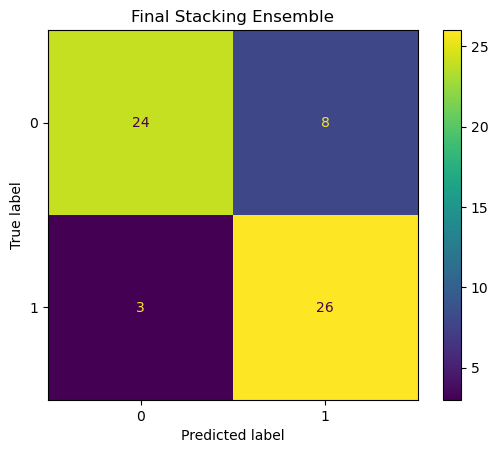

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(
    y_testc,
    final_pred
)
plt.title("Final Stacking Ensemble")
plt.show()